# Saari-style voting geometry in `VotingGeometry.jl`

This notebook is the Julia companion to the old `saari_geometry` Jupyter walkthrough. It shows the same geometry workflow, but through the monorepo architecture:

- `Preferences.jl` owns candidates, rankings, profiles, weights, restrictions, and linearization.
- `VotingGeometry.jl` owns canonical Saari bases, profile vectors, positional scoring, simplex maps, decomposition, and plotting.

The examples below are synthetic. They intentionally avoid survey loading, DataFrames, imputation, ESEB-specific cleaning, and the transfer routine, which are outside this first `VotingGeometry.jl` pass.


## 0. Setup

Run this notebook from either the repo root or `VotingGeometry/examples/`. The setup cell activates `VotingGeometry/` and instantiates the package environment. `MPLBACKEND` is set before loading `VotingGeometry` so the plotting cells work in headless notebook checks; remove that line for an interactive Matplotlib backend.


In [1]:
import Pkg

function votinggeometry_project()
    candidates = unique(abspath.([
        pwd(),
        joinpath(pwd(), "VotingGeometry"),
        joinpath(pwd(), ".."),
        joinpath(pwd(), "..", "VotingGeometry"),
    ]))
    for dir in candidates
        project = joinpath(dir, "Project.toml")
        if isfile(project) && occursin("name = \"VotingGeometry\"", read(project, String))
            return dir
        end
    end
    error("Could not locate VotingGeometry/Project.toml. Start Jupyter from the repo root or VotingGeometry/examples/.")
end

Pkg.activate(votinggeometry_project())
Pkg.instantiate()

ENV["MPLBACKEND"] = get(ENV, "MPLBACKEND", "Agg")

using LinearAlgebra
using Preferences
using VotingGeometry
using PythonPlot

VERSION


  Activating project at `~/Sync/Projects/polarization_paper/replication_package_reboot/VotingGeometry`


v"1.11.9"

## 1. API map

The old Python notebook mixed profile construction, table wrangling, geometry, scoring, and plotting. In the Julia package split, profile construction is delegated to `Preferences.jl`; `VotingGeometry.jl` starts once we have strict complete `Profile` or `WeightedProfile` objects.


In [2]:
api_inventory = [
    (responsibility = "candidate universe", package = "Preferences.jl", examples = "CandidatePool, candidates"),
    (responsibility = "ballots and profiles", package = "Preferences.jl", examples = "StrictRank, WeakRank, Profile, WeightedProfile"),
    (responsibility = "profile preprocessing", package = "Preferences.jl", examples = "linearize, restrict, weights"),
    (responsibility = "canonical Saari order", package = "VotingGeometry.jl", examples = "SaariBasis3, SaariBasis4"),
    (responsibility = "profile vectors", package = "VotingGeometry.jl", examples = "profile_vector, profile_counts"),
    (responsibility = "positional scoring", package = "VotingGeometry.jl", examples = "plurality_3a, borda_4c_q_s"),
    (responsibility = "simplex geometry", package = "VotingGeometry.jl", examples = "tern2cart, tetrahedron_points_from_profile"),
    (responsibility = "decomposition", package = "VotingGeometry.jl", examples = "decompose_profile, group_component"),
    (responsibility = "plots", package = "VotingGeometry.jl", examples = "plot_saari_triangle, plot_profile_tetrahedron_freqs"),
]


9-element Vector{@NamedTuple{responsibility::String, package::String, examples::String}}:
 (responsibility = "candidate universe", package = "Preferences.jl", examples = "CandidatePool, candidates")
 (responsibility = "ballots and profiles", package = "Preferences.jl", examples = "StrictRank, WeakRank, Profile, WeightedProfile")
 (responsibility = "profile preprocessing", package = "Preferences.jl", examples = "linearize, restrict, weights")
 (responsibility = "canonical Saari order", package = "VotingGeometry.jl", examples = "SaariBasis3, SaariBasis4")
 (responsibility = "profile vectors", package = "VotingGeometry.jl", examples = "profile_vector, profile_counts")
 (responsibility = "positional scoring", package = "VotingGeometry.jl", examples = "plurality_3a, borda_4c_q_s")
 (responsibility = "simplex geometry", package = "VotingGeometry.jl", examples = "tern2cart, tetrahedron_points_from_profile")
 (responsibility = "decomposition", package = "VotingGeometry.jl", examples = "decompo

## 2. Canonical orders

The Saari bases are not lexicographic permutation orders. Their explicit order is part of the mathematical interface, especially for the 24-dimensional decomposition. Always project `Preferences` profiles through `SaariBasis3` or `SaariBasis4` instead of hand-building vectors in a different order.


In [3]:
pool3_demo = CandidatePool([:Alckmin, :Bolsonaro, :Ciro])
basis3_demo = SaariBasis3(pool3_demo)

canonical3 = [
    (index = i, ranking = ranking_labels(basis3_demo)[i], ids = Tuple(canonical_permutations(basis3_demo)[i]))
    for i in eachindex(canonical_permutations(basis3_demo))
]


6-element Vector{@NamedTuple{index::Int64, ranking::String, ids::Tuple{Int64, Int64, Int64}}}:
 (index = 1, ranking = "Alckmin>Bolsonaro>Ciro", ids = (1, 2, 3))
 (index = 2, ranking = "Alckmin>Ciro>Bolsonaro", ids = (1, 3, 2))
 (index = 3, ranking = "Ciro>Alckmin>Bolsonaro", ids = (3, 1, 2))
 (index = 4, ranking = "Ciro>Bolsonaro>Alckmin", ids = (3, 2, 1))
 (index = 5, ranking = "Bolsonaro>Ciro>Alckmin", ids = (2, 3, 1))
 (index = 6, ranking = "Bolsonaro>Alckmin>Ciro", ids = (2, 1, 3))

In [4]:
pool4_demo = CandidatePool([:A, :B, :C, :D])
basis4_demo = SaariBasis4(pool4_demo)

canonical4 = [
    (index = i, ranking = ranking_labels(basis4_demo)[i], ids = Tuple(canonical_permutations(basis4_demo)[i]))
    for i in eachindex(canonical_permutations(basis4_demo))
]


24-element Vector{@NamedTuple{index::Int64, ranking::String, ids::NTuple{4, Int64}}}:
 (index = 1, ranking = "A>B>C>D", ids = (1, 2, 3, 4))
 (index = 2, ranking = "B>A>C>D", ids = (2, 1, 3, 4))
 (index = 3, ranking = "C>A>B>D", ids = (3, 1, 2, 4))
 (index = 4, ranking = "A>C>B>D", ids = (1, 3, 2, 4))
 (index = 5, ranking = "B>C>A>D", ids = (2, 3, 1, 4))
 (index = 6, ranking = "C>B>A>D", ids = (3, 2, 1, 4))
 (index = 7, ranking = "C>B>D>A", ids = (3, 2, 4, 1))
 (index = 8, ranking = "B>C>D>A", ids = (2, 3, 4, 1))
 (index = 9, ranking = "D>C>B>A", ids = (4, 3, 2, 1))
 (index = 10, ranking = "C>D>B>A", ids = (3, 4, 2, 1))
 (index = 11, ranking = "B>D>C>A", ids = (2, 4, 3, 1))
 (index = 12, ranking = "D>B>C>A", ids = (4, 2, 3, 1))
 (index = 13, ranking = "D>A>C>B", ids = (4, 1, 3, 2))
 (index = 14, ranking = "A>D>C>B", ids = (1, 4, 3, 2))
 (index = 15, ranking = "C>D>A>B", ids = (3, 4, 1, 2))
 (index = 16, ranking = "D>C>A>B", ids = (4, 3, 1, 2))
 (index = 17, ranking = "A>C>D>B", ids = (1

## 3. Building profiles from counts

The examples below use compact count vectors for readability. The helper expands counts into strict `Preferences.Profile` objects, then immediately projects them back through the canonical basis. In real code, upstream data should become `Profile` or `WeightedProfile` first; this helper is only for examples.


In [5]:
function profile_from_counts(pool::CandidatePool, basis::SaariBasis, counts)
    perms = canonical_permutations(basis)
    length(counts) == length(perms) || throw(ArgumentError("count vector length does not match basis"))

    sample = StrictRank(pool, collect(perms[1]))
    ballots = Vector{typeof(sample)}()
    for (perm, count) in zip(perms, counts)
        count >= 0 || throw(ArgumentError("counts must be nonnegative"))
        for _ in 1:Int(count)
            push!(ballots, StrictRank(pool, collect(perm)))
        end
    end
    return Profile(pool, ballots)
end

function profile_rows(basis, vector)
    labels = ranking_labels(basis)
    total = sum(vector)
    return [
        (index = i, ranking = labels[i], count = vector[i], share = total == 0 ? 0.0 : round(vector[i] / total; digits = 4))
        for i in eachindex(vector)
    ]
end

function positional_rows(methods, labels)
    rows = NamedTuple[]
    for (method, scores) in methods
        order = winner_order(scores, labels)
        for i in eachindex(labels)
            push!(rows, (
                method = method,
                candidate = labels[i],
                score = round(scores[i]; digits = 4),
                winner = labels[i] == order[1],
            ))
        end
    end
    return rows
end


positional_rows (generic function with 1 method)

## 4. Three candidates: a beverage profile

The 3-candidate canonical order is `ABC, ACB, CAB, CBA, BCA, BAC`. Here the candidates are `Tea`, `Milk`, and `Wine`. The counts are synthetic but chosen to make the geometric interpretation visible: plurality favors first-place support, while Borda and antiplurality respond to lower-rank information.


In [6]:
beverage_pool = CandidatePool([:Tea, :Milk, :Wine])
beverage_basis = SaariBasis3(beverage_pool)
beverage_counts = [4, 2, 7, 1, 9, 3]
beverage_profile = profile_from_counts(beverage_pool, beverage_basis, beverage_counts)

p3_freq = profile_vector(beverage_profile, beverage_basis; normalize = false)
p3_prop = profile_vector(beverage_profile, beverage_basis; normalize = true)

profile_rows(beverage_basis, p3_freq)


6-element Vector{@NamedTuple{index::Int64, ranking::String, count::Float64, share::Float64}}:
 (index = 1, ranking = "Tea>Milk>Wine", count = 4.0, share = 0.1538)
 (index = 2, ranking = "Tea>Wine>Milk", count = 2.0, share = 0.0769)
 (index = 3, ranking = "Wine>Tea>Milk", count = 7.0, share = 0.2692)
 (index = 4, ranking = "Wine>Milk>Tea", count = 1.0, share = 0.0385)
 (index = 5, ranking = "Milk>Wine>Tea", count = 9.0, share = 0.3462)
 (index = 6, ranking = "Milk>Tea>Wine", count = 3.0, share = 0.1154)

In [7]:
labels3 = Preferences.candidates(beverage_pool)
methods3 = [
    (:plurality, plurality_3a(p3_prop)),
    (:borda, borda_3a(p3_prop)),
    (:antiplurality, antiplurality_3a(p3_prop)),
]

positional_rows(methods3, labels3)


9-element Vector{NamedTuple}:
 (method = :plurality, candidate = :Tea, score = 0.2308, winner = false)
 (method = :plurality, candidate = :Milk, score = 0.4615, winner = true)
 (method = :plurality, candidate = :Wine, score = 0.3077, winner = false)
 (method = :borda, candidate = :Tea, score = 0.2821, winner = false)
 (method = :borda, candidate = :Milk, score = 0.3718, winner = true)
 (method = :borda, candidate = :Wine, score = 0.3462, winner = false)
 (method = :antiplurality, candidate = :Tea, score = 0.3077, winner = false)
 (method = :antiplurality, candidate = :Milk, score = 0.3269, winner = false)
 (method = :antiplurality, candidate = :Wine, score = 0.3654, winner = true)

### 4.1 The Saari triangle

`plot_saari_triangle` maps the three positional outcomes into the triangle whose vertices are the three candidates. The dashed segment connects plurality and antiplurality; the Borda point lies on that line in the 3-candidate positional family.


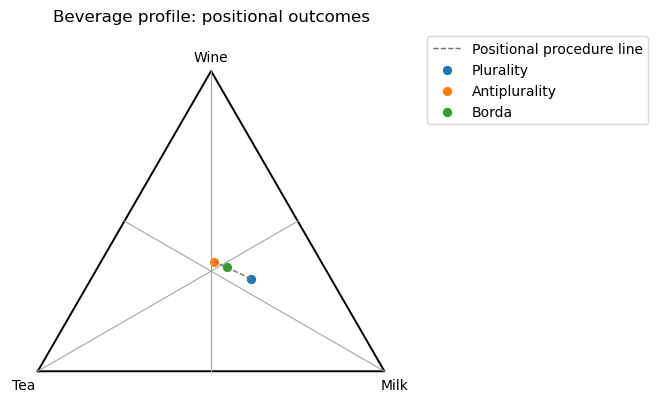

Python: <Axes: title={'center': 'Beverage profile: positional outcomes'}>

In [8]:
ax = plot_saari_triangle(p3_prop; labels = String.(labels3))
ax.set_title("Beverage profile: positional outcomes")
ax


In [9]:
triangle_points_from_profile(p3_prop)


Dict{Symbol, Tuple{Float64, Float64}} with 3 entries:
  :antiplurality => (0.509615, 0.316432)
  :borda         => (0.544872, 0.299778)
  :plurality     => (0.615385, 0.266469)

### 4.2 Weighted profiles use the same bridge

`WeightedProfile` lives in `Preferences.jl`. `VotingGeometry.profile_vector` reads the ballot weights and accumulates weighted mass in the same canonical coordinates.


In [10]:
weighted_ballots = [
    StrictRank(beverage_pool, [:Tea, :Milk, :Wine]),
    StrictRank(beverage_pool, [:Milk, :Wine, :Tea]),
    StrictRank(beverage_pool, [:Wine, :Tea, :Milk]),
]
weighted_profile = WeightedProfile(beverage_pool, weighted_ballots, [1.5, 3.0, 2.0])

weighted_freq = profile_vector(weighted_profile, beverage_basis; normalize = false)
weighted_prop = profile_vector(weighted_profile, beverage_basis; normalize = true)

(profile_rows(beverage_basis, weighted_freq), sum(weighted_prop))


(@NamedTuple{index::Int64, ranking::String, count::Float64, share::Float64}[(index = 1, ranking = "Tea>Milk>Wine", count = 1.5, share = 0.2308), (index = 2, ranking = "Tea>Wine>Milk", count = 0.0, share = 0.0), (index = 3, ranking = "Wine>Tea>Milk", count = 2.0, share = 0.3077), (index = 4, ranking = "Wine>Milk>Tea", count = 0.0, share = 0.0), (index = 5, ranking = "Milk>Wine>Tea", count = 3.0, share = 0.4615), (index = 6, ranking = "Milk>Tea>Wine", count = 0.0, share = 0.0)], 1.0)

### 4.3 Weak profiles must be linearized first

The geometry basis is over strict complete rankings. If upstream data has ties or incomplete ranks, use `Preferences.linearize` before projection. `VotingGeometry` intentionally refuses weak profiles instead of silently choosing a tie-break rule.


In [11]:
weak_profile = Profile(beverage_pool, [
    WeakRank(beverage_pool, Dict(:Tea => 1, :Milk => 1, :Wine => 2)),
])

try
    profile_vector(weak_profile, beverage_basis)
catch err
    sprint(showerror, err)
end


"ArgumentError: VotingGeometry requires strict complete profiles. Use Preferences.linearize first."

## 5. Four candidates: a Brazil-like synthetic profile

The next profile uses candidate names from the Brazil/ESEB domain but remains fully synthetic. It demonstrates the four-candidate canonical basis, positional scoring matrix, tetrahedron layouts, and 24-dimensional decomposition without any survey adapter.


In [12]:
brazil_pool = CandidatePool([:Alckmin, :Bolsonaro, :Ciro, :Haddad])
brazil_basis = SaariBasis4(brazil_pool)
labels4 = Preferences.candidates(brazil_pool)

brazil_counts = [
    18, 52, 25, 12, 20, 8,
    5, 7, 10, 9, 4, 12,
    8, 15, 9, 11, 13, 17,
    16, 10, 6, 8, 7, 14,
]

brazil_profile = profile_from_counts(brazil_pool, brazil_basis, brazil_counts)
p4_freq = profile_vector(brazil_profile, brazil_basis; normalize = false)
p4_prop = profile_vector(brazil_profile, brazil_basis; normalize = true)

(first(profile_rows(brazil_basis, p4_freq), 8), sum(p4_freq), sum(p4_prop))


(@NamedTuple{index::Int64, ranking::String, count::Float64, share::Float64}[(index = 1, ranking = "Alckmin>Bolsonaro>Ciro>Haddad", count = 18.0, share = 0.057), (index = 2, ranking = "Bolsonaro>Alckmin>Ciro>Haddad", count = 52.0, share = 0.1646), (index = 3, ranking = "Ciro>Alckmin>Bolsonaro>Haddad", count = 25.0, share = 0.0791), (index = 4, ranking = "Alckmin>Ciro>Bolsonaro>Haddad", count = 12.0, share = 0.038), (index = 5, ranking = "Bolsonaro>Ciro>Alckmin>Haddad", count = 20.0, share = 0.0633), (index = 6, ranking = "Ciro>Bolsonaro>Alckmin>Haddad", count = 8.0, share = 0.0253), (index = 7, ranking = "Ciro>Bolsonaro>Haddad>Alckmin", count = 5.0, share = 0.0158), (index = 8, ranking = "Bolsonaro>Ciro>Haddad>Alckmin", count = 7.0, share = 0.0222)], 316.0, 1.0)

## 6. Four-candidate positional procedures

The four-candidate positional family uses scoring vector `(1, s1, s2, 0)` with candidates as rows and the 24 canonical rankings as columns. The special methods below match the package API:

- plurality: `(s1, s2) = (0, 0)`
- vote for two: `(1, 0)`
- antiplurality: `(1, 1)`
- Borda: `(2/3, 1/3)`


In [13]:
standard_vote_matrix(0.25, 0.10)


4×24 Matrix{Float64}:
 1.0   0.25  0.25  1.0   0.1   0.1   …  0.25  1.0   0.1   0.1   1.0   0.25
 0.25  1.0   0.1   0.1   1.0   0.25     1.0   0.25  0.25  1.0   0.1   0.1
 0.1   0.1   1.0   0.25  0.25  1.0      0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0   0.0   0.0   0.0      0.1   0.1   1.0   0.25  0.25  1.0

In [14]:
methods4 = [
    (:plurality, plurality_4c_q_s(p4_freq)),
    (:vote_for_two, vote_for_two_4c_q_s(p4_freq)),
    (:antiplurality, antiplurality_4c_q_s(p4_freq)),
    (:borda, borda_4c_q_s(p4_freq)),
]

positional_rows(methods4, labels4)


16-element Vector{NamedTuple}:
 (method = :plurality, candidate = :Alckmin, score = 75.0, winner = false)
 (method = :plurality, candidate = :Bolsonaro, score = 107.0, winner = true)
 (method = :plurality, candidate = :Ciro, score = 73.0, winner = false)
 (method = :plurality, candidate = :Haddad, score = 61.0, winner = false)
 (method = :vote_for_two, candidate = :Alckmin, score = 103.5, winner = true)
 (method = :vote_for_two, candidate = :Bolsonaro, score = 83.0, winner = false)
 (method = :vote_for_two, candidate = :Ciro, score = 73.0, winner = false)
 (method = :vote_for_two, candidate = :Haddad, score = 56.5, winner = false)
 (method = :antiplurality, candidate = :Alckmin, score = 89.6667, winner = true)
 (method = :antiplurality, candidate = :Bolsonaro, score = 81.0, winner = false)
 (method = :antiplurality, candidate = :Ciro, score = 85.0, winner = false)
 (method = :antiplurality, candidate = :Haddad, score = 60.3333, winner = false)
 (method = :borda, candidate = :Alckmin, s

### 6.1 Comparison regions over the positional-method simplex

The admissible scoring simplex is `0 <= s2 <= s1 <= 1`. The package helper below sweeps a grid over that triangle and overlays score-comparison regions under `q_s_4candidates`, so a point can belong to more than one highlighted comparison.


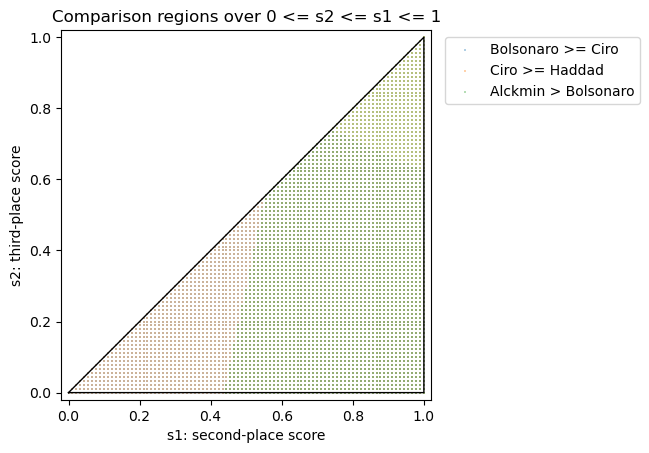

Python: <Axes: title={'center': 'Comparison regions over 0 <= s2 <= s1 <= 1'}, xlabel='s1: second-place score', ylabel='s2: third-place score'>

In [15]:
plot_positional_comparison_regions(p4_freq, labels4; resolution = 91)


## 7. Candidate dropping and the three-candidate triangle

Alternative-set sensitivity is handled by `Preferences.restrict`, not by `VotingGeometry`. After restricting a profile to three candidates, we build a `SaariBasis3` for the restricted candidate pool and use the usual triangle tools.


In [16]:
drop_rows = NamedTuple[]
for dropped in labels4
    keep = [candidate for candidate in labels4 if candidate != dropped]
    restricted_profile, restricted_pool, _ = restrict(brazil_profile, keep)
    restricted_basis = SaariBasis3(restricted_pool)
    restricted_vector = profile_vector(restricted_profile, restricted_basis; normalize = true)
    borda_scores = borda_3a(restricted_vector)
    push!(drop_rows, (
        dropped = dropped,
        kept = join(String.(keep), ", "),
        borda_winner = winner_order(borda_scores, keep)[1],
        plurality_winner = winner_order(plurality_3a(restricted_vector), keep)[1],
        antiplurality_winner = winner_order(antiplurality_3a(restricted_vector), keep)[1],
    ))
end

drop_rows


4-element Vector{NamedTuple}:
 (dropped = :Alckmin, kept = "Bolsonaro, Ciro, Haddad", borda_winner = :Bolsonaro, plurality_winner = :Bolsonaro, antiplurality_winner = :Ciro)
 (dropped = :Bolsonaro, kept = "Alckmin, Ciro, Haddad", borda_winner = :Alckmin, plurality_winner = :Alckmin, antiplurality_winner = :Alckmin)
 (dropped = :Ciro, kept = "Alckmin, Bolsonaro, Haddad", borda_winner = :Alckmin, plurality_winner = :Bolsonaro, antiplurality_winner = :Alckmin)
 (dropped = :Haddad, kept = "Alckmin, Bolsonaro, Ciro", borda_winner = :Alckmin, plurality_winner = :Bolsonaro, antiplurality_winner = :Alckmin)

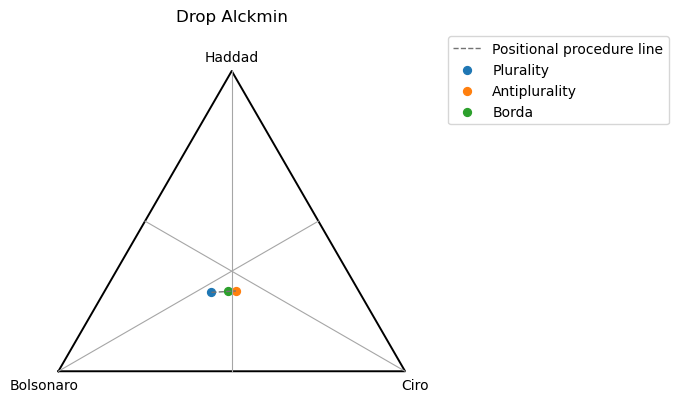

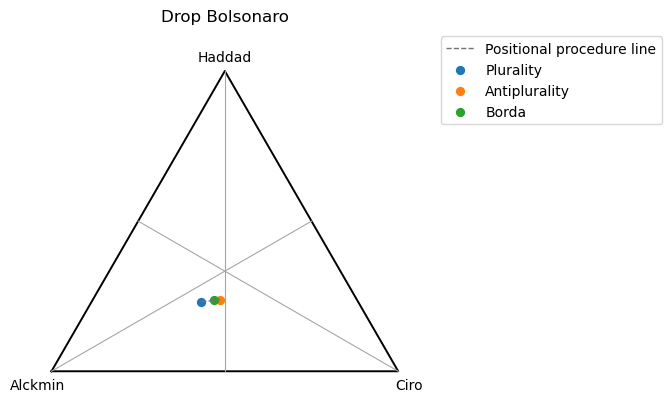

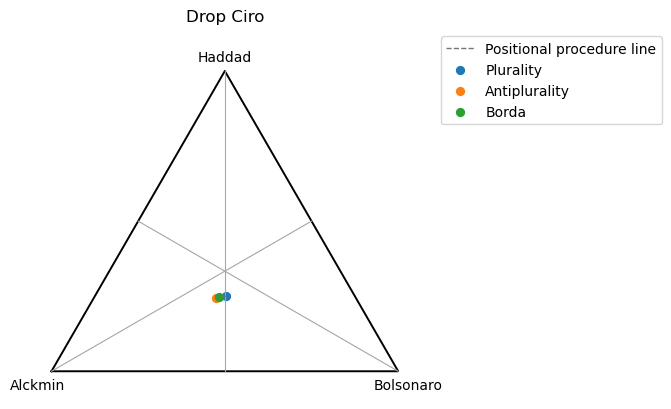

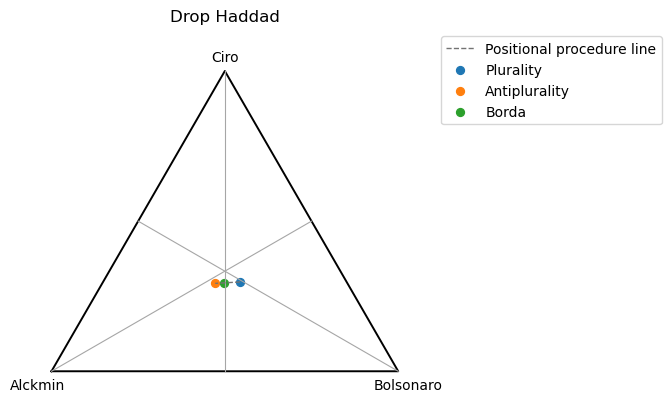

In [17]:
for dropped in labels4
    keep = [candidate for candidate in labels4 if candidate != dropped]
    restricted_profile, restricted_pool, _ = restrict(brazil_profile, keep)
    restricted_basis = SaariBasis3(restricted_pool)
    restricted_vector = profile_vector(restricted_profile, restricted_basis; normalize = true)
    ax_drop = plot_saari_triangle(restricted_vector; labels = String.(keep))
    ax_drop.set_title("Drop $(String(dropped))")
end

nothing


## 8. Tetrahedral views of four-candidate profiles

The opened tetrahedron places the 24 canonical ranking frequencies on a flat layout. The 3D tetrahedron shows the four-candidate outcome simplex. The same barycentric machinery also maps positional outcomes to Cartesian tetrahedron coordinates.


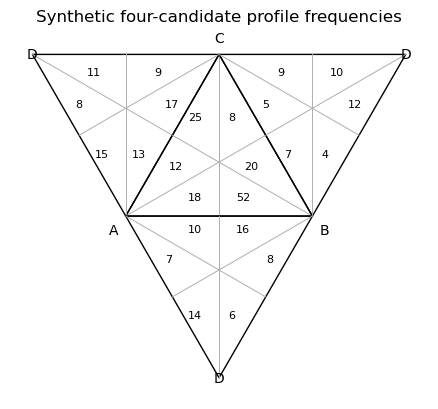

Python: <Axes: title={'center': 'Synthetic four-candidate profile frequencies'}>

In [18]:
ax = plot_profile_tetrahedron_freqs(p4_freq; textsize = 8, title = "Synthetic four-candidate profile frequencies")
ax


In [19]:
outcome_functions = (
    plurality = plurality_4c_q_s,
    vote_for_two = vote_for_two_4c_q_s,
    antiplurality = antiplurality_4c_q_s,
    borda = borda_4c_q_s,
)

tetrahedron_points_from_profile(p4_freq, outcome_functions)


Dict{Symbol, Tuple{Float64, Float64, Float64}} with 4 entries:
  :antiplurality => (0.486287, 0.288066, 0.155892)
  :borda         => (0.49077, 0.270557, 0.152878)
  :plurality     => (0.550633, 0.255788, 0.157615)
  :vote_for_two  => (0.467563, 0.251677, 0.145988)

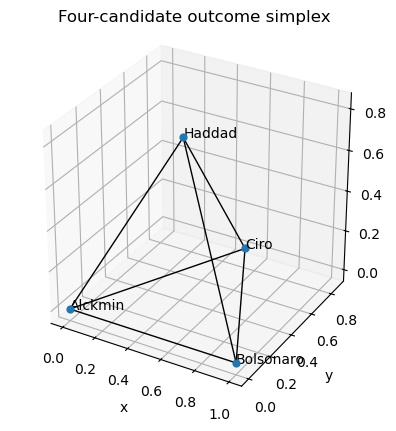

Python: <Axes3D: title={'center': 'Four-candidate outcome simplex'}, xlabel='x', ylabel='y', zlabel='z'>

In [20]:
ax = plot_saari_tetrahedron3d(; labels = String.(labels4))
ax.set_title("Four-candidate outcome simplex")
ax


## 9. The 24-dimensional Saari decomposition

The decomposition matrix is defined over the 24 canonical four-candidate ranking frequencies. `decompose_profile` stores coefficients and the 24 component vectors. Components can be reconstructed individually, by label groups, or all together.


In [21]:
check_basis_identity()


true

In [22]:
dec = decompose_profile(p4_freq)
reconstruction_error = maximum(abs.(reconstruct(dec) .- p4_freq))

nonzero_coefficients = [
    (index = i, label = COMPONENT_LABELS[i], coefficient = round(dec.coefficients[i]; digits = 4))
    for i in eachindex(COMPONENT_LABELS)
    if abs(dec.coefficients[i]) > 1e-9
]

(reconstruction_error, nonzero_coefficients)


(7.105427357601002e-15, @NamedTuple{index::Int64, label::Symbol, coefficient::Float64}[(index = 1, label = :Da, coefficient = -0.0417), (index = 2, label = :Db, coefficient = -4.2083), (index = 3, label = :Dc, coefficient = -1.9167), (index = 4, label = :departure_subset_1, coefficient = -7.5), (index = 5, label = :departure_subset_2, coefficient = -7.3333), (index = 6, label = :departure_subset_3, coefficient = 2.5), (index = 7, label = :departure_subset_4, coefficient = 6.1667), (index = 8, label = :departure_subset_5, coefficient = 1.5), (index = 9, label = :departure_subset_6, coefficient = 6.6667), (index = 10, label = :departure_subset_7, coefficient = 11.8333)  …  (index = 15, label = :Cabcd, coefficient = 0.375), (index = 16, label = :Cabdc, coefficient = 3.375), (index = 17, label = :Cacbd, coefficient = 3.75), (index = 18, label = :K, coefficient = 13.1667), (index = 19, label = :double_reversal_ac, coefficient = 5.625), (index = 20, label = :double_reversal_cb, coefficient =

In [23]:
groups = [
    :departure_differentials,
    :subset_departures,
    :basic_profile_differentials,
    :condorcet,
    :kernel,
    :double_reversals,
]

group_summary = [
    (
        group = group,
        l1_mass = round(sum(abs, group_component(dec, group)); digits = 4),
        nonzero_entries = count(x -> abs(x) > 1e-9, group_component(dec, group)),
    )
    for group in groups
]


6-element Vector{@NamedTuple{group::Symbol, l1_mass::Float64, nonzero_entries::Int64}}:
 (group = :departure_differentials, l1_mass = 182.6667, nonzero_entries = 24)
 (group = :subset_departures, l1_mass = 235.3333, nonzero_entries = 24)
 (group = :basic_profile_differentials, l1_mass = 94.6667, nonzero_entries = 24)
 (group = :condorcet, l1_mass = 60.0, nonzero_entries = 24)
 (group = :kernel, l1_mass = 316.0, nonzero_entries = 24)
 (group = :double_reversals, l1_mass = 126.0, nonzero_entries = 24)

In [24]:
condorcet_component = group_component(dec, :condorcet)
double_reversal_component = group_component(dec, :double_reversals)

(
    condorcet_first_six = round.(condorcet_component[1:6]; digits = 4),
    double_reversal_first_six = round.(double_reversal_component[1:6]; digits = 4),
)


(condorcet_first_six = [0.375, 3.75, 3.375, -0.375, -3.75, -3.375], double_reversal_first_six = [10.75, 5.625, -5.625, 9.625, -9.625, -10.75])

## 10. Minimal workflow template

This is the reusable shape for new analysis code. The input is already a `Preferences.Profile` or `Preferences.WeightedProfile`; survey loading and group construction should happen upstream.


In [25]:
function analyze_saari_profile(profile, basis::SaariBasis)
    freqs = profile_vector(profile, basis; normalize = false)
    props = profile_vector(profile, basis; normalize = true)
    labels = Preferences.candidates(basis.pool)

    if length(freqs) == 6
        methods = [
            (:plurality, plurality_3a(props)),
            (:borda, borda_3a(props)),
            (:antiplurality, antiplurality_3a(props)),
        ]
        return (
            frequencies = freqs,
            proportions = props,
            positional_results = positional_rows(methods, labels),
            triangle_points = triangle_points_from_profile(props),
        )
    elseif length(freqs) == 24
        methods = [
            (:plurality, plurality_4c_q_s(freqs)),
            (:vote_for_two, vote_for_two_4c_q_s(freqs)),
            (:antiplurality, antiplurality_4c_q_s(freqs)),
            (:borda, borda_4c_q_s(freqs)),
        ]
        dec = decompose_profile(freqs)
        return (
            frequencies = freqs,
            proportions = props,
            positional_results = positional_rows(methods, labels),
            decomposition = dec,
            reconstruction_error = maximum(abs.(reconstruct(dec) .- freqs)),
        )
    else
        throw(ArgumentError("Saari workflow expects a 3- or 4-candidate basis"))
    end
end

analysis4 = analyze_saari_profile(brazil_profile, brazil_basis)
analysis4.reconstruction_error


7.105427357601002e-15

## 11. Exercises

1. Change `beverage_counts` so plurality and Borda choose different winners, then redraw the Saari triangle.
2. Convert the beverage example to a `WeightedProfile` with fractional weights and compare normalized and unnormalized vectors.
3. Modify `brazil_counts` and rerun the positional-method comparison simplex. Look for profiles where comparison regions overlap or disappear.
4. Use `Preferences.restrict` to compare all three-candidate subprofiles and record which candidate-dropping choice changes the Borda winner.
5. Reconstruct only the `:condorcet` and `:double_reversals` decomposition groups and inspect which canonical rankings carry the largest signed mass.
6. Add a `PrefPol` adapter later that returns a strict `Preferences.Profile`, then reuse `analyze_saari_profile` without changing `VotingGeometry`.

Not included yet: transfer-algorithm examples. That routine was deliberately left out of the first `VotingGeometry.jl` pass.
